In [1]:
import tensorflow as tf
import torch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.18.0


In [2]:
!pip install optuna
import optuna
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizer

In [3]:
from google.colab import files
uploaded = files.upload()


data = pd.read_csv('yelp_review_100k.csv', nrows=70000)

Saving yelp_review_100k.csv to yelp_review_100k (3).csv


In [4]:
# Display dataset structure
print(data.head())

                                                text  stars sentiment
0  If you decide to eat here, just be aware it is...      3   neutral
1  I've taken a lot of spin classes over the year...      5  positive
2  Family diner. Had the buffet. Eclectic assortm...      3   neutral
3  Wow!  Yummy, different,  delicious.   Our favo...      5  positive
4  Cute interior and owner (?) gave us tour of up...      4  positive


In [5]:
# Preprocessing function
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = text.lower()  # Convert to lowercase
    text = text.strip()  # Remove leading/trailing whitespace
    return text

In [6]:
# Apply preprocessing
data['cleaned_text'] = data['text'].apply(preprocess_text)

In [7]:
# Tokenization for DistilBERT
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
data['distilbert_tokens'] = data['cleaned_text'].apply(lambda x: distilbert_tokenizer.encode(x, truncation=True, padding='max_length', max_length=100))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
# Splitting dataset
X_distilbert = np.array(data['distilbert_tokens'].tolist())
y = data['sentiment']

In [9]:
X_train_distilbert, X_test_distilbert, y_train_distilbert, y_test_distilbert = train_test_split(
    X_distilbert, y, test_size=0.2, random_state=42
)

In [10]:
# Save preprocessed data for later use
np.save('X_train_distilbert.npy', X_train_distilbert)
np.save('X_test_distilbert.npy', X_test_distilbert)

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

def model_init():
    from transformers import DistilBertForSequenceClassification
    return DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

In [12]:
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 2e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.3),
    }

In [13]:
# Example label mapping
label_map = {"negative": 0, "neutral": 1, "positive": 2}

# Apply mapping if necessary
y_train_distilbert = [label_map[label] if isinstance(label, str) else label for label in y_train_distilbert]
y_test_distilbert = [label_map[label] if isinstance(label, str) else label for label in y_test_distilbert]

In [14]:
!pip install datasets

from datasets import Dataset

train_data = {"text": X_train_distilbert, "label": y_train_distilbert}
val_data = {"text": X_test_distilbert, "label": y_test_distilbert}

# Convert to Hugging Face Datasets
train_dataset = Dataset.from_dict(train_data)
val_dataset = Dataset.from_dict(val_data)


In [15]:
def tokenize_function(example):
    return distilbert_tokenizer(example["text"], padding="max_length", truncation=True)

# Convert NumPy arrays to lists of strings for compatibility
train_dataset = Dataset.from_dict({"text": [" ".join(map(str, x)) for x in train_dataset["text"]], "label": train_dataset["label"]})
val_dataset = Dataset.from_dict({"text": [" ".join(map(str, x)) for x in val_dataset["text"]], "label": val_dataset["label"]})

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/56000 [00:00<?, ? examples/s]

Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

In [16]:
print(train_dataset[0]["label"])
print(type(train_dataset[0]["label"]))

tensor(2)
<class 'torch.Tensor'>


In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    fp16=True if torch.cuda.is_available() else False,
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=distilbert_tokenizer,
    compute_metrics=compute_metrics,
)

study_name = "distilbert_hpo_shared"
storage_url = "sqlite:///distilbert_shared_study.db"

best_run = trainer.hyperparameter_search(
    direction="maximize",
    hp_space=optuna_hp_space,
    n_trials=10,
    backend="optuna",
    study_name=study_name,
    storage=storage_url,
    load_if_exists=True
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-17-da62207a5459>:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-04-11 03:25:14,299] A new study created in RDB with name: distilbert_hpo_shared
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly i

Epoch,Training Loss,Validation Loss,Accuracy
1,0.591400,0.558583,0.783643
2,0.521800,0.546705,0.793500
3,0.483600,0.517012,0.803286


[I 2025-04-11 03:32:57,940] Trial 0 finished with value: 0.8032857142857143 and parameters: {'learning_rate': 4.53573073152648e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 16, 'weight_decay': 0.2468225996058533}. Best is trial 0 with value: 0.8032857142857143.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


eval/accuracy,▁▅█
eval/loss,█▆▁
eval/runtime,▁▆█
eval/samples_per_second,█▃▁
eval/steps_per_second,█▃▁
train/epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▆▆▆▆▇▇▇████
train/global_step,▁▁▂▂▂▃▃▃▃▄▄▅▅▅▆▆▆▆▇▇▇████
train/grad_norm,▁▃▃▃▅▂▄▃▁▄▂▄▄▅▃▆▅▆█▇▃
train/learning_rate,██▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▁▁
train/loss,█▆▅▄▄▄▄▃▃▃▃▂▂▂▂▁▂▁▁▁▁
eval/accuracy,0.80329


Epoch,Training Loss,Validation Loss,Accuracy
1,0.548900,0.528269,0.791214
2,0.479100,0.508532,0.801000


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.585200,0.533897,0.792214
2,0.493500,0.508738,0.804929
3,0.460900,0.502787,0.810286
4,0.417400,0.498222,0.809714
5,0.379600,0.501893,0.811429


[I 2025-04-11 04:16:52,026] Trial 8 finished with value: 0.8114285714285714 and parameters: {'learning_rate': 4.589828601125568e-05, 'num_train_epochs': 5, 'per_device_train_batch_size': 32, 'weight_decay': 0.24567971770886304}. Best is trial 2 with value: 0.8132142857142857.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


eval/accuracy,▁▆█▇█
eval/loss,█▃▂▁▂
eval/runtime,▂▄▁▁█
eval/samples_per_second,▇▅██▁
eval/steps_per_second,▇▅██▁
train/epoch,▁▁▂▂▂▃▃▄▄▄▄▅▅▅▆▆▇▇▇▇███
train/global_step,▁▁▂▂▂▃▃▄▄▄▄▅▅▅▆▆▇▇▇▇███
train/grad_norm,▁▂▂▅▄▁▆▃▅▁▇▄▂▃█▅▂
train/learning_rate,██▇▇▆▆▅▅▄▄▄▃▃▂▂▁▁
train/loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁
eval/accuracy,0.81143


Epoch,Training Loss,Validation Loss,Accuracy
1,0.564400,0.542308,0.784357


[I 2025-04-11 04:19:25,860] Trial 9 pruned. 


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from trainer
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Print metrics
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.66      0.64      0.65      2611
     Neutral       0.37      0.11      0.17      1620
    Positive       0.83      0.93      0.88      9769

    accuracy                           0.78     14000
   macro avg       0.62      0.56      0.57     14000
weighted avg       0.75      0.78      0.76     14000



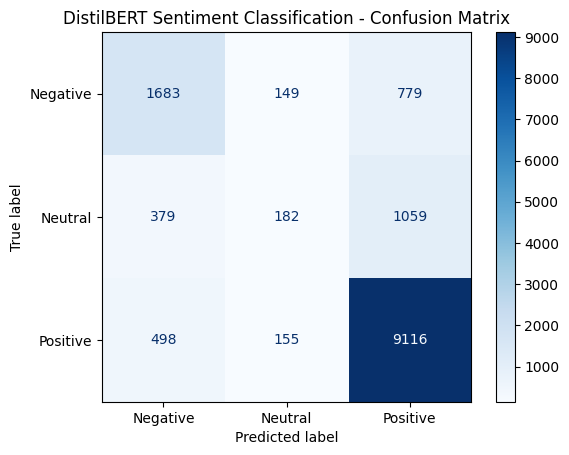

In [19]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("DistilBERT Sentiment Classification - Confusion Matrix")
plt.show()


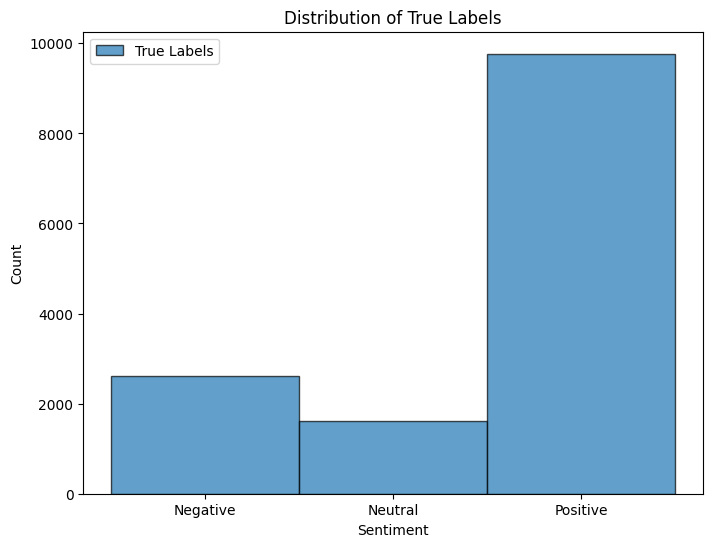

In [20]:
# Visualize the distribution of true labels
plt.figure(figsize=(8, 6))
plt.hist(y_true, bins=np.arange(4) - 0.5, edgecolor='black', alpha=0.7, label='True Labels')
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.title("Distribution of True Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.legend()
plt.show()

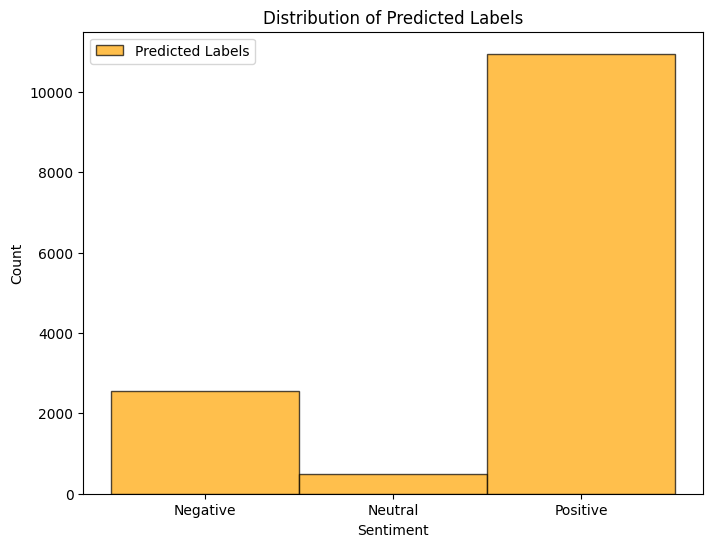

In [21]:
# Visualize the distribution of predicted labels
plt.figure(figsize=(8, 6))
plt.hist(y_pred, bins=np.arange(4) - 0.5, edgecolor='black', alpha=0.7, label='Predicted Labels', color='orange')
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"])
plt.title("Distribution of Predicted Labels")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.legend()
plt.show()

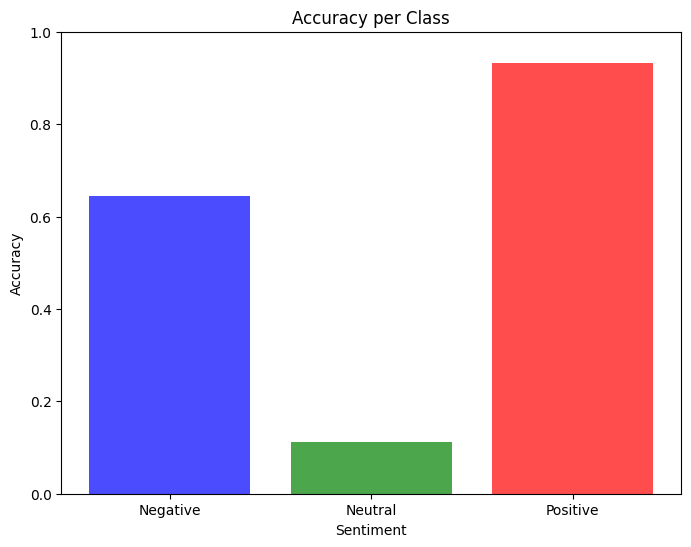

In [22]:
# Bar plot for accuracy per class
class_accuracies = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 6))
plt.bar(["Negative", "Neutral", "Positive"], class_accuracies, color=['blue', 'green', 'red'], alpha=0.7)
plt.title("Accuracy per Class")
plt.xlabel("Sentiment")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

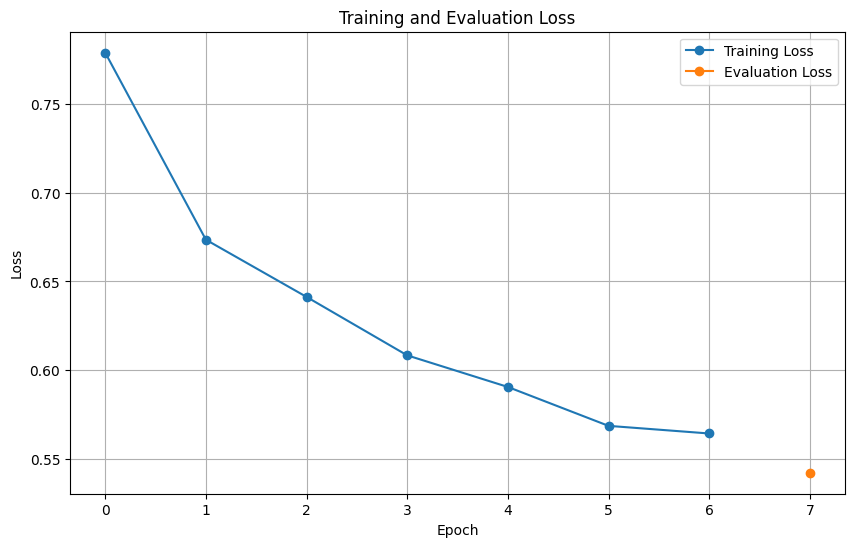

In [23]:
# Extract training logs
logs = trainer.state.log_history

# Convert logs to a DataFrame for easier plotting
logs_df = pd.DataFrame(logs)

# Plot training and evaluation loss
plt.figure(figsize=(10, 6))
if "loss" in logs_df.columns:
    plt.plot(logs_df[logs_df["loss"].notnull()]["loss"], label="Training Loss", marker='o')
if "eval_loss" in logs_df.columns:
    plt.plot(logs_df[logs_df["eval_loss"].notnull()]["eval_loss"], label="Evaluation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Evaluation Loss")
plt.legend()
plt.grid()
plt.show()

<ipython-input-24-3fa129630475>:10: ExperimentalWarning:

plot_slice is experimental (supported from v2.2.0). The interface can change in the future.



AttributeError: 'numpy.ndarray' object has no attribute 'show'

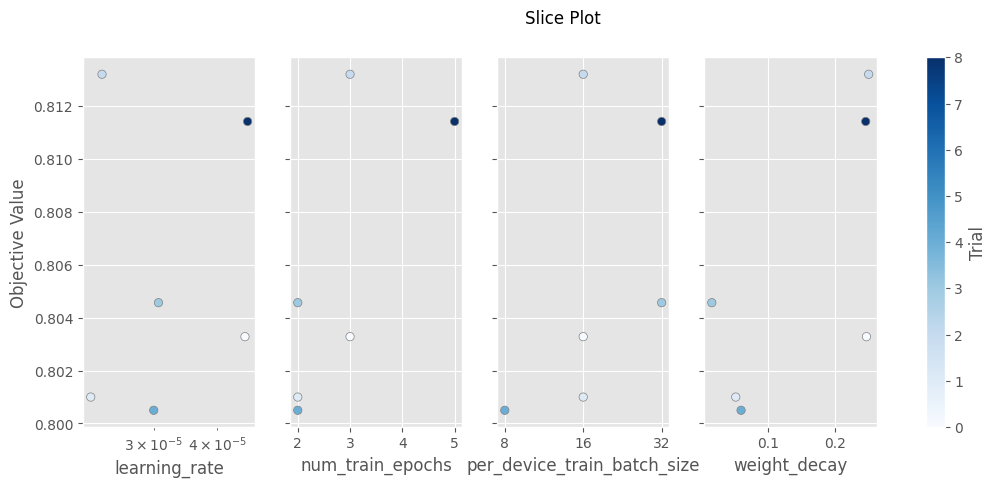

In [24]:
import optuna.visualization.matplotlib as optuna_viz
from optuna.visualization import plot_param_importances
import matplotlib.pyplot as plt

# Load the persisted study
study = optuna.load_study(study_name="distilbert_hpo_shared", storage="sqlite:///distilbert_shared_study.db")

# Plot anything from the original study
plot_param_importances(study).show()
optuna_viz.plot_slice(study).show()
optuna_viz.plot_optimization_history(study).show()
optuna_viz.plot_contour(study).show()


In [25]:
from optuna.visualization import plot_param_importances
import optuna.visualization.matplotlib as optuna_viz

# Generate the hyperparameter importance plot
fig = plot_param_importances(study)
fig.show()

<ipython-input-26-8321578880c7>:2: ExperimentalWarning:

plot_slice is experimental (supported from v2.2.0). The interface can change in the future.

<ipython-input-26-8321578880c7>:5: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



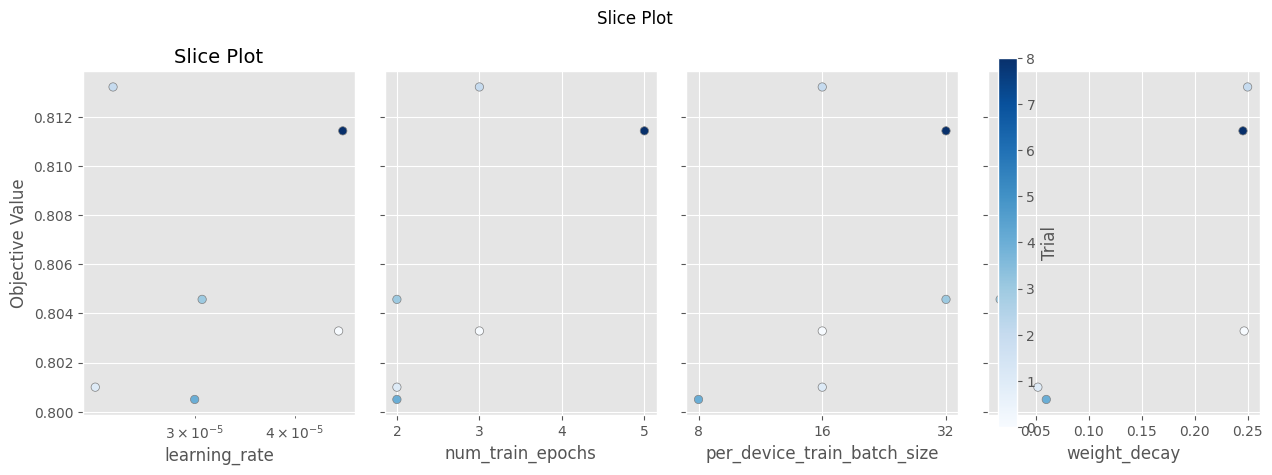

In [26]:
# Slice Plot
fig = optuna_viz.plot_slice(study)
if isinstance(fig, np.ndarray) and len(fig) > 0:
    fig[0].set_title("Slice Plot", fontsize=14)
plt.tight_layout()
plt.show()

<ipython-input-27-1a5c793a4308>:2: ExperimentalWarning:

plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.



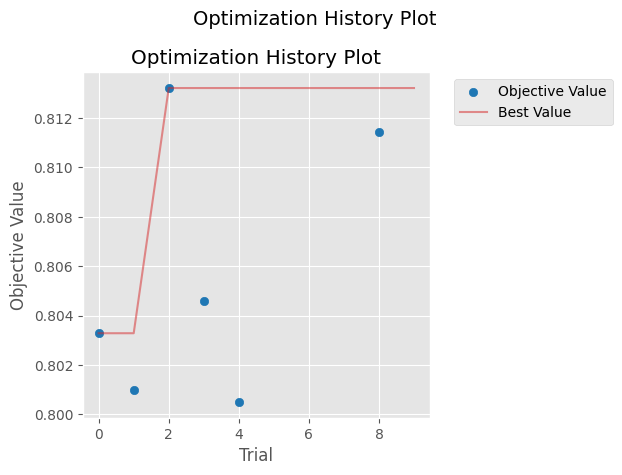

In [27]:
# Optimization History Plot
fig = optuna_viz.plot_optimization_history(study)
plt.suptitle("Optimization History Plot", fontsize=14)
plt.tight_layout()
plt.show()

<ipython-input-28-ff455cd15cc8>:2: ExperimentalWarning:

plot_contour is experimental (supported from v2.2.0). The interface can change in the future.

[W 2025-04-11 04:22:19,041] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.
<ipython-input-28-ff455cd15cc8>:4: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



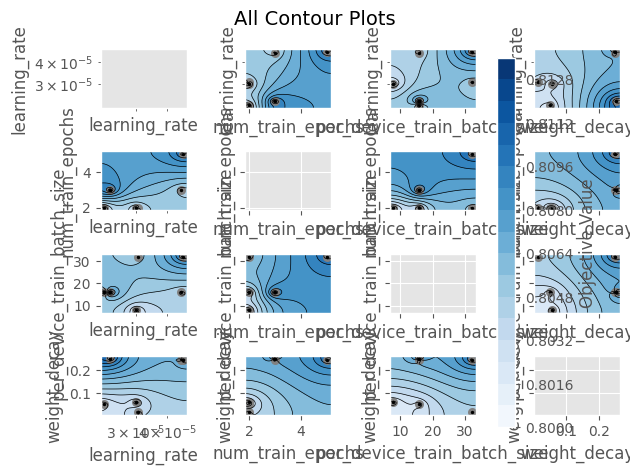

In [28]:
# Full Contour Plot (all combinations)
fig = optuna_viz.plot_contour(study)
plt.suptitle("All Contour Plots", fontsize=14)
plt.tight_layout()
plt.show()

<ipython-input-29-98abff41bd69>:2: ExperimentalWarning:

plot_contour is experimental (supported from v2.2.0). The interface can change in the future.

[W 2025-04-11 04:22:21,628] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.


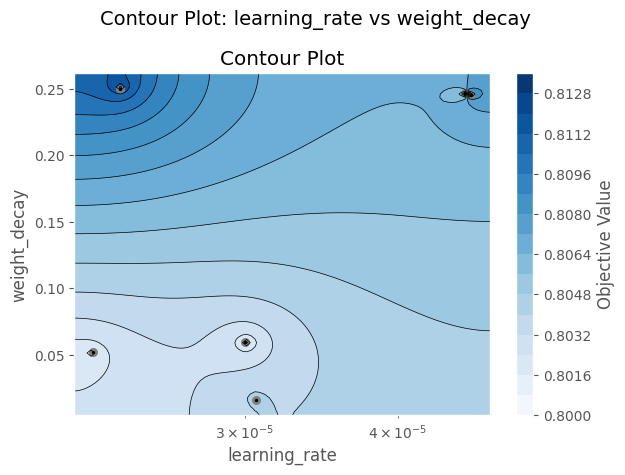

In [29]:
# Individual Contour Plots
fig = optuna_viz.plot_contour(study, params=["learning_rate", "weight_decay"])
plt.suptitle("Contour Plot: learning_rate vs weight_decay", fontsize=14)
plt.tight_layout()
plt.show()